# Asteroid Sonification
Adrián García Riber 2025, SVO.

#### Dependencies 

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from numpy.lib.stride_tricks import sliding_window_view

import cv2
import sounddevice as sd

### NOTE: Introduce the route to your asteroid folder

In [2]:
folder = 'AsteroidSample'

#### Definitions

In [3]:
def load_image (route):
    image = mpimg.imread(route)
    imgplot = plt.imshow(image)
    plt.show()
    return image

In [4]:
def filtering (channel, threshold):
    height_dim = channel.shape[0]
    width_dim = channel.shape[1]
    alpha_dim = channel.shape[2]
    filtered_img= np.ones((height_dim, width_dim, alpha_dim))
    for i in range(height_dim):
        for j in range(width_dim):
            if channel [i][j][0] < threshold:
                filtered_img [i][j][0] = 0.01 #channel [i][j][0] #0.01 #White
    return (filtered_img)

In [5]:
def show_filter (filtered_img):
    plt.imshow(filtered_img [:,:,0], cmap='Blues')
    plt.show()

In [6]:
def save_for_gif (filtered_img, index):
    plt.imshow(filtered_img [:,:,0], cmap='Blues')
    plt.savefig(f'frame_{index}.png')
    plt.show()

In [7]:
def find_asteroid_coordinates(image, patch_size):
    
    windows = sliding_window_view(image[:, :, 0], (patch_size, patch_size))
    patch_sums = windows.sum(axis=(2, 3))

    y, x = np.unravel_index(np.argmin(patch_sums), patch_sums.shape)
    return (x, y+6)

In [8]:
def save_with_coord (image, coord, patch_size, index):
    
    fig, ax = plt.subplots()
    img_grey = np.mean(image[..., :3], axis=2)

    ax.imshow(img_grey, cmap='Blues')
    rect = patches.Rectangle(coord, patch_size, patch_size,
                            linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    plt.savefig(f'frame_{index}.png')
    plt.show()


In [9]:
def sine_wave_generator(freq, duration, sample_rate):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    return amplitude * np.sin(2 * np.pi * freq * t)

## Pre-procesing .png files

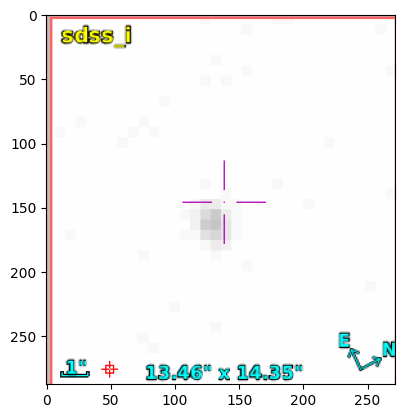

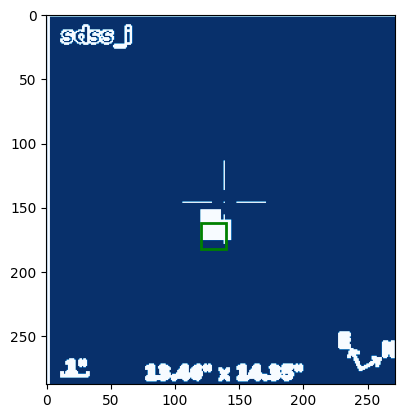

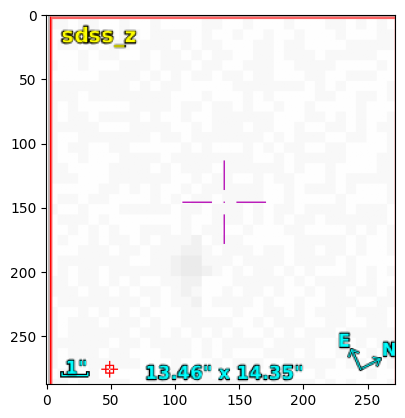

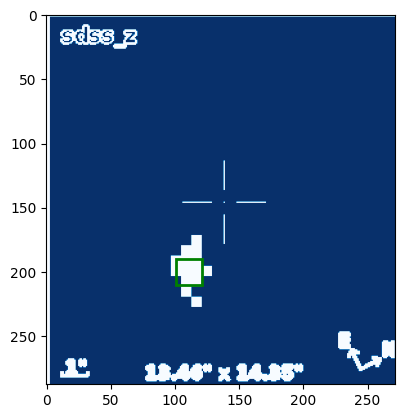

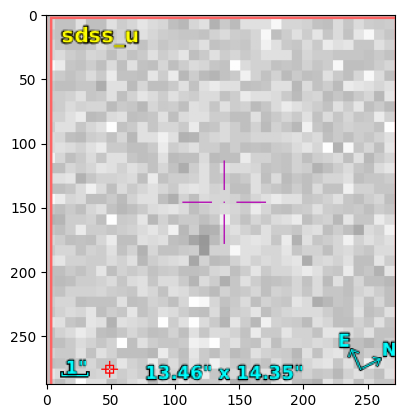

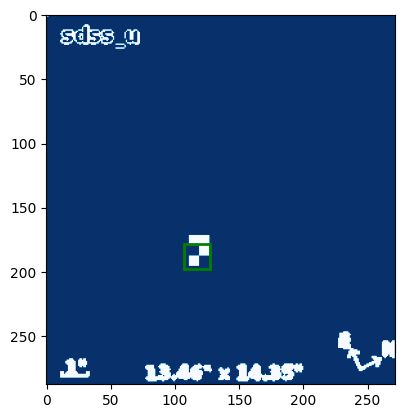

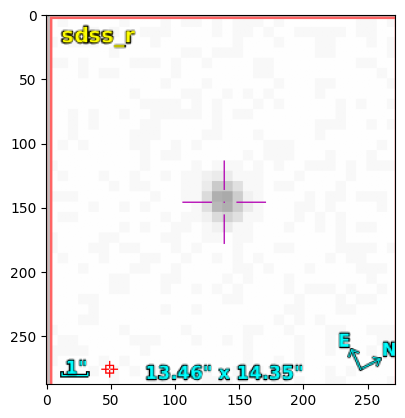

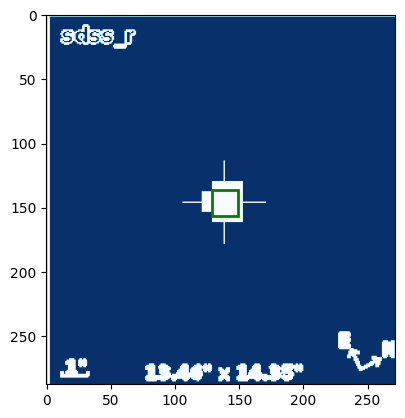

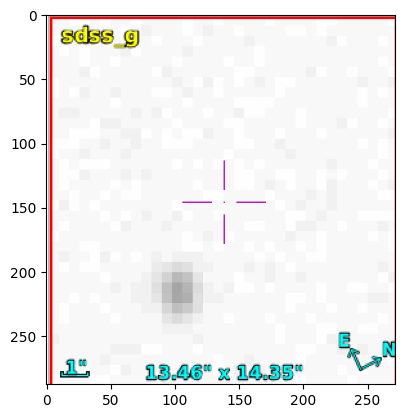

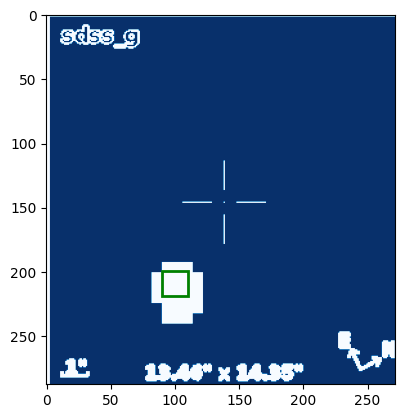

In [10]:
patch_size = 20
freqs = np.zeros(5)
pan = np.zeros(5)

for file in os.listdir(folder):
    file_name = os.path.join(folder,file)
    channel = load_image(file_name)
    channel_name = file_name.split('/')[1]
    
    if channel_name.startswith("r"): 
        threshold = 0.9         #r channel: threshold = 0.9
        frame = 0        
    if channel_name.startswith("i"): 
        threshold = 0.9         #i channel: threshold = 0.9
        frame = 1
    if channel_name.startswith("u"): 
        threshold = 0.66        #u channel: threshold = 0.66
        frame = 2
    if channel_name.startswith("z"): 
        threshold = 0.95        #z channel: threshold = 0.95  
        frame = 3
    if channel_name.startswith("g"): 
        threshold = 0.9         #g channel: threshold = 0.9
        frame = 4

    filtered = filtering(channel, threshold)
    coord = find_asteroid_coordinates(filtered, patch_size)
    freqs[frame] = (100000*1/coord[1])-250
    pan[frame] = coord[0]
 
    save_with_coord(filtered, coord, patch_size, frame)

## Generating a filtered .gif

In [11]:
images = [Image.open(f"frame_{i}.png") for i in range(5)]
images[0].save(
    'Asteroid.gif',
    save_all=True,
    append_images=images[1:],
    duration=600,    # milliseconds per frame
    loop=1           # loop forever
)

## Multimodal representation

In [12]:
freqs

array([485.29411765, 367.28395062, 311.79775281, 276.31578947,
       252.51256281])

In [13]:
pan

array([129., 120., 107., 101.,  90.])

#### NOTE: Restart the kernel and run all cells to repeat the representation
(Since the graphic's window moves to the background when clicking in the notebook after playback)

In [14]:
image_files = ['frame_0.png','frame_1.png', 'frame_2.png', 'frame_3.png', 'frame_4.png']
fps = 12
duration = 8.0 / fps
sample_rate = 44100
amplitude = 0.1
A_weights = np.ones(len(freqs))

for i, img_file in enumerate(image_files):
    img = cv2.imread(img_file)
     
    start_freq = freqs[i% len(freqs)]
    if 0<i<4:
        end_freq = freqs[(i+1) % len(freqs)]
    else:
        end_freq = freqs[i % len(freqs)]

    if freqs[(i) % len(freqs)] >= 700:
        A_weights [(i) % len(freqs)] = 0.4
#audio--------------------------------
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

    inst_freq = np.linspace(start_freq, end_freq, t.size)
    phase = 2 * np.pi * np.cumsum(inst_freq) / sample_rate
    wave = 0.1*A_weights[i% len(freqs)]*np.sin(phase)

    attack_time = 0.3
    release_time = 0.3
    
    # Create envelope
    attack_samples = int(sample_rate * attack_time)
    release_samples = int(sample_rate * release_time)
    sustain_samples = len(wave) - attack_samples - release_samples
    
    attack_env = np.linspace(0, 1, attack_samples)
    sustain_env = np.ones(sustain_samples)
    release_env = np.linspace(1, 0, release_samples)
    
    envelope = np.concatenate((attack_env, sustain_env, release_env))
    enveloped_wave = wave * envelope   
    
    left_channel = enveloped_wave * (260 - pan[i% len(freqs)])/260
    right_channel = enveloped_wave * pan[i% len(freqs)]/200
    
    stereo_wave = np.vstack((left_channel, right_channel)).T  # shape (samples, 2)

    #Play sound-----------------------------
    sd.play(stereo_wave, sample_rate)
    
    #Display image--------------------------
    cv2.imshow('Sequential Images', img)
    if cv2.waitKey(int(duration * 1000)) & 0xFF == 27:  # ESC to quit
        break
sd.stop()
cv2.destroyAllWindows()